# GISLR — Sentences: a continuous multi-sign test set from GISLR_Stratified's test split

**What this notebook does.** Pipeline stage (dataset build), not a diagnostic.
GISLR is isolated-sign only, so there is no way to measure how a model copes
with a *stream* of signs: boundaries, carry-over between signs, non-sign
movement. This builds that test set, **GISLR-Sentences v1**, from real clips
only, and uploads it to Kaggle (TODO §12.1):

1. **Sentences**: 1,757 ASL-gloss-order sentences over the 250-gloss
   vocabulary, committed and versioned in `sb.recognize.sequences`
   (`corpus_data/sentences.v1/`, 11 themed files). Validated here: every
   token is in the vocabulary, length 2–8, no duplicates, and every gloss
   appears in ≥ 12 sentences.
2. **Two splits, both built only from `test.csv`** (18,896 clips, 21 signers):
   - `sentence`: meaningful sentences. Planning is coverage-driven, so
     **every test clip is used**; a slot re-uses an already-placed clip only
     when no sentence can be completed from unused ones (~8%, every such
     slot flagged in `reused`).
   - `control`: the same clips in random order, each exactly once, with
     sequence lengths drawn from the `sentence` split. Same signers, same
     clips, no meaning: comparing the two isolates what a language prior
     buys later.
3. **Synthesized non-sign frames**, labelled null (GISLR clips are trimmed
   to the sign: 0 hand-absent lead-in/lead-out frames measured on 1,500 clips):
   - 2–10 *transition* frames between signs, linearly interpolated from
     the end of one clip to the start of the next;
   - 10–30 *rest* frames at each end, with the body held still plus jitter
     and **both hands absent (NaN)**, which is what MediaPipe emits while the
     hands are down.

**Artifacts** (`data/cache/gislr/sentences/v1/`; the whole folder is what gets uploaded):

| path | content |
|---|---|
| `sequences/sentence/sNNNNN.npz`, `sequences/control/cNNNNN.npz` | `landmarks (T,543,3) float32` NaN kept, **canonical row order** · `frame_labels (T,) int16` (−1 = null) · `frame_kind (T,) uint8` (0 sign, 1 transition, 2 rest) · `segments (n,2) int32` start/end-exclusive · `labels (n,) int16` |
| `sequences.csv` | one row per sequence: kind, sentence_id, participant, glosses, labels, starts, ends, source_uids, reused, gaps, rest lengths, n_frames, npz path |
| `sentences.csv` / `lexicon.v1.json` / `sign_to_prediction_index_map.json` | the corpus, POS tags, label map |
| `plan.json` | the full clip-assignment plan (it determines every sequence byte for byte) |
| `build_info.json` | config, seed, corpus sha256, source dataset reference, planner stats |
| `roundtrip_sample.json` | seeded sample of sequences re-checked against their source clips |
| `README.md` | dataset card |
| `assets/*.png` | length / coverage / exemplar figures |

**Resumability.** The plan is computed once and written before anything else
(`plan.json`, with the config hash). If the config changes, the plan is
recomputed and the sequences are rebuilt. Materialization is manifest-driven
(`manifest.json`: each npz is written atomically, then marked `done`; `done`
units are skipped and `failed` units retried). The upload is gated by
`UPLOAD = False`.

**Design decisions vs the TODO §12.1 spec:**
- *One signer per sequence* (each test signer covers 221–249 of the 250
  glosses). A real signer does not change body and camera position at every
  sign boundary, so mixing signers would make boundaries trivially easy.
- *Canonical row order on disk.* The source npz files use a different row
  order (`gislr_stratified.CANONICAL_TO_STORED`). It is undone once here, so
  this dataset reads with no permutation, exactly like `sb.core.schema`
  describes.
- *float32, not the schema's float16 storage type*, so every sign segment
  is **bit-identical** to its source clip (§5 checks this).
- *The hard-cut variant is not stored separately*: `frame_kind == 0`
  recovers back-to-back concatenation exactly.
- **Caveat**: `test.csv` is also the canonical val set, which every existing
  checkpoint was early-stopped on. Baselines scored on this set carry that
  (small) selection advantage; the continuous model (§12.3) must select on
  a `train.csv`-derived set instead.

## Setup

In [1]:
# ============================================================
# Imports, tunables, resolved paths
# ============================================================
import hashlib
import json
import os
import shutil
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sb.core.paths import CACHE_DIR, EXPERIMENTS_DIR, gislr_dir
from sb.core.vocab import LABEL_MAP_FILE, load_label_map
from sb.recognize.sequences import compose, corpus

CONFIG_PATH = EXPERIMENTS_DIR / "recognition" / "configs" / "gislr.sentences.json"
CONFIG = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
CONFIG_SHA = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()

UPLOAD = False  # flip to True to push the finished folder to Kaggle (private)
N_WORKERS = 8   # materialization threads (zlib releases the GIL)

DATA_DIR = gislr_dir()
OUT_DIR = CACHE_DIR / "gislr" / "sentences" / CONFIG["dataset_version"]
SEQ_DIR = OUT_DIR / "sequences"
ASSETS_DIR = OUT_DIR / "assets"
PLAN_PATH = OUT_DIR / "plan.json"
MANIFEST_PATH = OUT_DIR / "manifest.json"
for d in (SEQ_DIR, ASSETS_DIR):
    d.mkdir(parents=True, exist_ok=True)


def write_json(path: Path, obj) -> None:
    tmp = path.with_suffix(".tmp")
    tmp.write_text(json.dumps(obj, indent=1), encoding="utf-8")
    os.replace(tmp, path)


print(f"source:  {DATA_DIR}  ({CONFIG['source_split']}.csv)")
print(f"output:  {OUT_DIR}")
print(f"config:  {CONFIG_PATH.name}  sha256={CONFIG_SHA[:12]}")
print(f"corpus:  {corpus.sentences_dir(CONFIG['corpus_version'])}  "
      f"sha256={corpus.corpus_sha256(CONFIG['corpus_version'])[:12]}")

source:  C:\Users\user2\.cache\kagglehub\datasets\bracu23101281\gislr-stratified\versions\1  (test.csv)
output:  C:\Users\user2\repository\data\cache\gislr\sentences\v1
config:  gislr.sentences.json  sha256=8dfc2cdb9eb6
corpus:  C:\Users\user2\repository\packages\sb-recognize\src\sb\recognize\sequences\corpus_data\sentences.v1  sha256=daeca9e5e82a


## 1. Validate the sentence corpus

Hard failures raise (a token outside the vocabulary, a length outside 2–8, a
duplicate sentence); coverage is reported. A random sample of sentences is
printed for review. The corpus is committed text, so a wording change is a
new `sentences.vN/` directory and a new dataset version, never an in-place
edit.

In [2]:
# ============================================================
# Corpus validation + a review sample
# ============================================================
N_SAMPLE = 30  # sentences printed for review

src_df = pd.read_csv(DATA_DIR / f"{CONFIG['source_split']}.csv")
sentences = corpus.load_sentences(CONFIG["corpus_version"])
lexicon = corpus.load_lexicon(CONFIG["corpus_version"])
assert set(lexicon) == set(src_df["sign"]), "lexicon and vocabulary disagree"
report = corpus.validate(sentences, src_df["sign"].unique(), **CONFIG["corpus"])

print(f"{report['n_sentences']} sentences in {report['n_themes']} themes, "
      f"mean length {report['mean_len']:.2f}, length histogram {report['length_hist']}")
cov = pd.Series(report["coverage"]).sort_values()
print(f"gloss coverage (sentences containing it): min {cov.min()} ({cov.index[0]}), "
      f"median {cov.median():.0f}, max {cov.max()} ({cov.index[-1]})")
print(f"missing: {report['missing'] or 'none'}   below minimum: {report['thin'] or 'none'}")
print()
rng = np.random.default_rng(CONFIG["seed"])
for i in rng.choice(len(sentences), N_SAMPLE, replace=False):
    s = sentences[i]
    print(f"  {s.id:<22} {' '.join(g.upper() for g in s.glosses)}")

1757 sentences in 11 themes, mean length 3.14, length histogram {2: 511, 3: 655, 4: 441, 5: 131, 6: 15, 7: 4}
gloss coverage (sentences containing it): min 12 (owl), median 16, max 155 (minemy)
missing: none   below minimum: none

  home-153               GO HOME NOW
  food-080               FOOD EMPTY
  feelings-039           MINEMY THINK NO
  stories-159            OWL NIGHT MOON TREE
  animals-154            PUPPY FINISH MILK
  body-006               MINEMY TONGUE OWIE
  clothes-036            HAT FIREMAN RED
  stories-115            HEN WHITE BROWN
  stories-042            DOG NOSE WET
  play-060               GIFT OPEN NOW
  body-066               TOUCH CHIN
  clothes-066            SHIRT PRETTY
  weather_time-093       WAIT THERE
  food-060               BROTHER HATE CARROT LIKE FRENCHFRIES
  stories-138            TIGER CUTE PUPPY SAME
  stories-041            NOSE RED CLOWN PRETEND
  family-083             COWBOY RIDE HORSE
  play-131               WEUS GO POOL AFTER FOOD
  fam

## 2. Plan: assign every test clip to a sequence

`compose.plan_sentences` loops: take the signer with the most unused clips,
score every sentence that signer can sign (fraction of its slots fillable
from unused clips, a reuse penalty, a small bonus for length, and a pull
toward the glosses the signer has most left), and fill the best one. It
stops when every clip is placed. `compose.plan_control` then re-uses every
clip exactly once in random order.

The plan fully determines the dataset. It is written once, keyed by the
config hash; if the config changes, the plan is recomputed and the old
sequences are discarded.

In [3]:
# ============================================================
# Plan both splits (cached in plan.json, keyed by config hash)
# ============================================================
if PLAN_PATH.exists() and json.loads(PLAN_PATH.read_text())["config_sha256"] == CONFIG_SHA:
    PLAN = json.loads(PLAN_PATH.read_text())
    print(f"plan loaded from {PLAN_PATH.name}")
else:
    if SEQ_DIR.exists() and any(SEQ_DIR.rglob("*.npz")):
        print("config changed -- discarding previously built sequences")
        shutil.rmtree(SEQ_DIR)
        MANIFEST_PATH.unlink(missing_ok=True)
    src_df = pd.read_csv(DATA_DIR / f"{CONFIG['source_split']}.csv")
    sentences = corpus.load_sentences(CONFIG["corpus_version"])
    rng = np.random.default_rng(CONFIG["seed"])
    synth = dict(gap_range=tuple(CONFIG["synth"]["gap_frames"]),
                 rest_range=tuple(CONFIG["synth"]["rest_frames"]))
    bar = tqdm(total=len(src_df), desc="plan sentence split")
    sent_plan, stats = compose.plan_sentences(
        src_df, sentences, rng, **synth, **CONFIG["planner"],
        progress=lambda done, total: bar.update(done - bar.n))
    bar.close()
    lengths = np.array([len(r["glosses"]) for r in sent_plan])
    ctrl_plan = compose.plan_control(src_df, lengths, rng, **synth)
    for i, r in enumerate(sent_plan):
        r["seq_id"] = f"s{i:05d}"
    for i, r in enumerate(ctrl_plan):
        r["seq_id"] = f"c{i:05d}"
    PLAN = {"config_sha256": CONFIG_SHA, "stats": stats,
            "sequences": sent_plan + ctrl_plan}
    write_json(PLAN_PATH, PLAN)
    print(f"plan written to {PLAN_PATH.name}")

rows = PLAN["sequences"]
st = PLAN["stats"]
n_sent = sum(r["kind"] == "sentence" for r in rows)
print(f"sentence split: {n_sent} sequences, {st['n_slots']} sign slots, "
      f"{st['n_clips']} clips used, reuse {st['reuse_rate']:.1%}, "
      f"orphans {st['n_orphan_clips']}, {st['n_distinct_sentences']} distinct sentences")
print(f"control split:  {len(rows) - n_sent} sequences, "
      f"{sum(len(r['glosses']) for r in rows if r['kind'] == 'control')} sign slots (each clip once)")

plan loaded from plan.json
sentence split: 6616 sequences, 20547 sign slots, 18896 clips used, reuse 8.0%, orphans 0, 1227 distinct sentences
control split:  6111 sequences, 18896 sign slots (each clip once)


## 3. Materialize the sequences (resumable)

One npz per plan row. Each sequence has its own RNG, seeded from
`(seed, row index)`, used only for rest-frame jitter, so any single
sequence rebuilds identically regardless of order or interruption.
Manifest: each npz is written atomically, then marked `done`; `done` is
skipped, `failed` retried.

In [4]:
# ============================================================
# Build every sequence npz (manifest-driven, resumable)
# ============================================================
PLAN = json.loads(PLAN_PATH.read_text())
rows = PLAN["sequences"]
src_df = pd.read_csv(DATA_DIR / f"{CONFIG['source_split']}.csv")
relpath_of = dict(zip(src_df["uid"], src_df["npz_relpath"]))
label_of = load_label_map(DATA_DIR)
manifest = json.loads(MANIFEST_PATH.read_text()) if MANIFEST_PATH.exists() else {}


def build(i_row):
    i, row = i_row
    rel = f"sequences/{row['kind']}/{row['seq_id']}.npz"
    try:
        arrays = compose.materialize(
            row, DATA_DIR, relpath_of, label_of,
            np.random.default_rng([CONFIG["seed"], i]),
            rest_jitter=CONFIG["synth"]["rest_jitter"])
        compose.write_sequence(OUT_DIR / rel, arrays)
        return row["seq_id"], {"status": "done",
                               **compose.summarize_row(row, arrays, row["seq_id"], rel)}
    except Exception as e:  # recorded, retried on the next run
        return row["seq_id"], {"status": "failed", "error": repr(e)}


todo = [(i, r) for i, r in enumerate(rows) if manifest.get(r["seq_id"], {}).get("status") != "done"]
bar = tqdm(total=len(rows), initial=len(rows) - len(todo), desc="materialize")
n_failed = 0
with ThreadPoolExecutor(N_WORKERS) as ex:
    for k, (seq_id, rec) in enumerate(ex.map(build, todo), 1):
        manifest[seq_id] = rec
        n_failed += rec["status"] == "failed"
        bar.update(1)
        bar.set_postfix(failed=n_failed)
        if k % 500 == 0:
            write_json(MANIFEST_PATH, manifest)
write_json(MANIFEST_PATH, manifest)
bar.close()
done = sum(v["status"] == "done" for v in manifest.values())
print(f"{done}/{len(rows)} done, {n_failed} failed this run")

materialize: 100%|##########| 12727/12727 [00:00<?, ?it/s]

12727/12727 done, 0 failed this run


## 4. Index, corpus copy, build record, dataset card

`sequences.csv` is assembled from the manifest (only `done` rows), so it
never lists a file that does not exist.

In [5]:
# ============================================================
# sequences.csv, sentences.csv, lexicon, label map, build_info, README
# ============================================================
PLAN = json.loads(PLAN_PATH.read_text())
manifest = json.loads(MANIFEST_PATH.read_text())
failed = [k for k, v in manifest.items() if v["status"] != "done"]
assert not failed, f"{len(failed)} sequences not done -- re-run section 3 first: {failed[:5]}"

order = [r["seq_id"] for r in PLAN["sequences"]]
seq_df = pd.DataFrame([{k: v for k, v in manifest[s].items() if k != "status"} for s in order])
seq_df.to_csv(OUT_DIR / "sequences.csv", index=False)

sentences = corpus.load_sentences(CONFIG["corpus_version"])
pd.DataFrame([{"sentence_id": s.id, "theme": s.theme, "glosses": " ".join(s.glosses)}
              for s in sentences]).to_csv(OUT_DIR / "sentences.csv", index=False)
shutil.copy(corpus.lexicon_path(CONFIG["corpus_version"]), OUT_DIR / f"lexicon.{CONFIG['corpus_version']}.json")
shutil.copy(DATA_DIR / LABEL_MAP_FILE, OUT_DIR / LABEL_MAP_FILE)

frames = seq_df.groupby("kind")["n_frames"].agg(["count", "sum", "mean", "max"])
build_info = {
    "dataset": "GISLR-Sentences",
    "dataset_version": CONFIG["dataset_version"],
    "config": CONFIG,
    "config_sha256": CONFIG_SHA,
    "corpus_sha256": corpus.corpus_sha256(CONFIG["corpus_version"]),
    "source": {"kaggle_ref": "bracu23101281/gislr-stratified",
               "resolved_dir": str(DATA_DIR), "split": CONFIG["source_split"]},
    "planner_stats": PLAN["stats"],
    "frames": frames.reset_index().to_dict(orient="records"),
    "size_bytes": sum(p.stat().st_size for p in SEQ_DIR.rglob("*.npz")),
}
write_json(OUT_DIR / "build_info.json", build_info)

s_stats = PLAN["stats"]
card = f"""# GISLR-Sentences {CONFIG['dataset_version']}

Continuous multi-sign landmark sequences built from **real** isolated-sign clips of
GISLR_Stratified's `test.csv` (`bracu23101281/gislr-stratified`, 18,896 clips, 21 signers,
250 glosses). The signed clips are unmodified; only the non-sign frames between and around
them are synthesized. Made for evaluating streaming/continuous recognizers and sign-boundary
reset (signbridge TODO §12).

## Splits
- **sentence** ({(seq_df.kind == 'sentence').sum()} sequences): {s_stats['n_distinct_sentences']} distinct
  ASL-gloss-order sentences from a {len(sentences)}-sentence corpus. Every test clip is used;
  {s_stats['reuse_rate']:.1%} of sign slots re-use an already-placed clip (flagged in `reused`).
- **control** ({(seq_df.kind == 'control').sum()} sequences): the same clips in random order, each
  exactly once, with lengths drawn from the sentence split.

One signer per sequence, always.

## Files
- `sequences/<kind>/<seq_id>.npz`: `landmarks (T,543,3) float32` (NaN = not detected; canonical
  GISLR holistic row order: face 0-467, left_hand 468-488, pose 489-521, right_hand 522-542),
  `frame_labels (T,) int16` (-1 = null), `frame_kind (T,) uint8` (0 sign, 1 transition, 2 rest),
  `segments (n,2) int32` (start, end-exclusive, per sign), `labels (n,) int16`.
- `sequences.csv`: one row per sequence, including source clip uids and all segment boundaries.
- `sentences.csv`, `lexicon.{CONFIG['corpus_version']}.json`, `{LABEL_MAP_FILE}`, `plan.json`, `build_info.json`.

## Synthesized frames (labelled -1)
- **transition**: {CONFIG['synth']['gap_frames'][0]}-{CONFIG['synth']['gap_frames'][1]} frames between signs,
  linearly interpolated from the last frame of one clip to the first frame of the next.
- **rest**: {CONFIG['synth']['rest_frames'][0]}-{CONFIG['synth']['rest_frames'][1]} frames at each end, with the body
  held still plus Gaussian jitter (sd {CONFIG['synth']['rest_jitter']}) and both hands NaN.

`landmarks[frame_kind == 0]` is exactly the back-to-back concatenation of the source clips.

## Caveats
- The non-sign frames are synthetic; real transitions (co-articulation) and real rest poses are
  not in GISLR. Treat scores here as an upper bound on real continuous signing.
- GISLR_Stratified's test split is also the canonical validation split of the signbridge
  isolated-sign models, so those models were checkpoint-selected on these clips.
- The sentences follow ASL gloss order but are simple: the vocabulary is a toddler-level
  word list with no first/second-person pronouns other than `minemy`/`yourself`/`weus`.
"""
(OUT_DIR / "README.md").write_text(card, encoding="utf-8")
print(frames)
print(f"size on disk: {build_info['size_bytes'] / 1e9:.2f} GB")

          count      sum        mean  max
kind                                     
control    6111  1041154  170.373752  939
sentence   6616  1125262  170.081923  830
size on disk: 12.12 GB


## 5. Checks and figures

- **Round-trip** on a seeded sample: every segment slices back to its
  source clip bit for bit, and labels/kinds agree with the segments.
  The sample ids are recorded in `roundtrip_sample.json`.
- **Label consistency on every sequence** (from `sequences.csv`, no npz
  reads): segments are ordered, non-overlapping and inside the sequence.
- Figures: sequence-length distribution per split, clip-use distribution,
  and one exemplar sequence with its segments shaded.

In [6]:
# ============================================================
# Round-trip sample + index-level consistency
# ============================================================
PLAN = json.loads(PLAN_PATH.read_text())
by_id = {r["seq_id"]: r for r in PLAN["sequences"]}
seq_df = pd.read_csv(OUT_DIR / "sequences.csv", keep_default_na=False)
src_df = pd.read_csv(DATA_DIR / f"{CONFIG['source_split']}.csv")
relpath_of = dict(zip(src_df["uid"], src_df["npz_relpath"]))

rng = np.random.default_rng(CONFIG["seed"])
sample = sorted(rng.choice(seq_df["seq_id"], CONFIG["n_roundtrip_checks"], replace=False).tolist())
bad = []
for seq_id in tqdm(sample, desc="round-trip"):
    row = seq_df.set_index("seq_id").loc[seq_id]
    arrays = compose.read_sequence(OUT_DIR / row["npz_relpath"])
    try:
        compose.check_roundtrip(arrays, by_id[seq_id], DATA_DIR, relpath_of)
    except AssertionError as e:
        bad.append((seq_id, str(e)))
write_json(OUT_DIR / "roundtrip_sample.json", {"seed": CONFIG["seed"], "seq_ids": sample, "failures": bad})
print(f"round-trip: {len(sample) - len(bad)}/{len(sample)} sequences exact")

issues = 0
for r in seq_df.itertuples():
    s = np.array(r.starts.split(), int)
    e = np.array(r.ends.split(), int)
    ok = (len(s) == r.n_signs and (e > s).all() and (s[1:] >= e[:-1]).all()
          and s[0] >= r.rest_in and e[-1] <= r.n_frames - r.rest_out)
    issues += not ok
print(f"segment-consistency issues across {len(seq_df)} sequences: {issues}")

used = pd.Series(" ".join(seq_df.loc[seq_df.kind == "sentence", "source_uids"]).split()).value_counts()
print(f"sentence split: {used.size}/{len(src_df)} test clips used; uses per clip "
      f"{used.value_counts().sort_index().to_dict()}")

round-trip:   0%|          | 0/300 [00:00<?, ?it/s]

round-trip: 300/300 sequences exact
segment-consistency issues across 12727 sequences: 0
sentence split: 18896/18896 test clips used; uses per clip {1: 17560, 2: 1102, 3: 176, 4: 41, 5: 13, 6: 2, 7: 2}


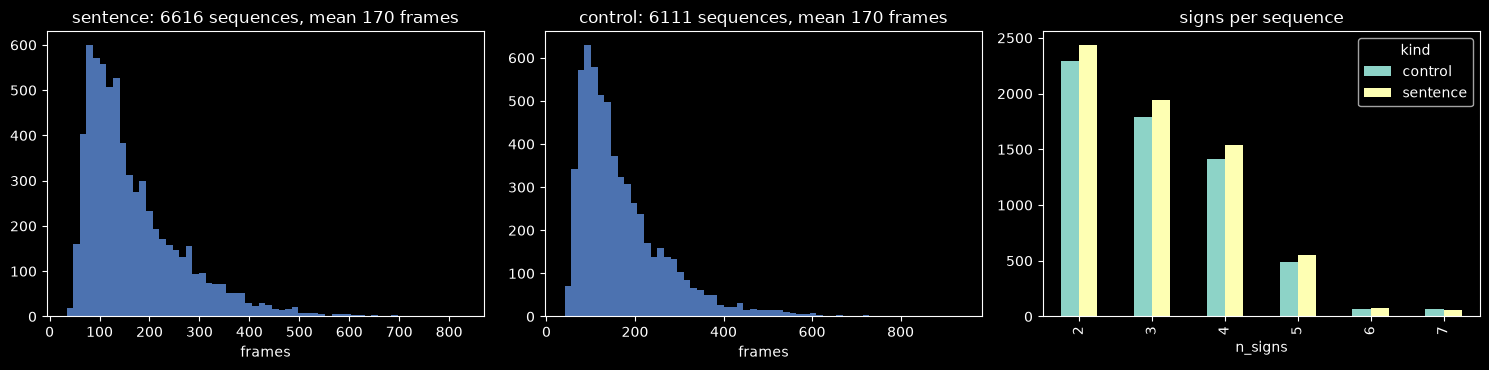

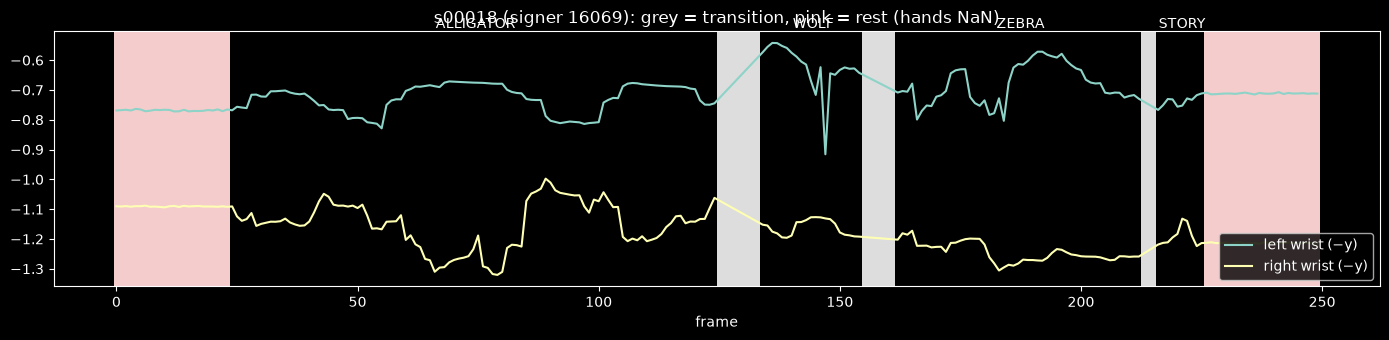

In [7]:
# ============================================================
# Figures: lengths, clip use, one exemplar sequence
# ============================================================
seq_df = pd.read_csv(OUT_DIR / "sequences.csv", keep_default_na=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for kind, ax in zip(("sentence", "control"), axes[:2]):
    sub = seq_df[seq_df.kind == kind]
    ax.hist(sub["n_frames"], bins=60, color="#4c72b0")
    ax.set_title(f"{kind}: {len(sub)} sequences, mean {sub.n_frames.mean():.0f} frames")
    ax.set_xlabel("frames")
counts = seq_df.groupby("kind")["n_signs"].value_counts().unstack(0).fillna(0)
counts.plot.bar(ax=axes[2])
axes[2].set_title("signs per sequence")
fig.tight_layout()
fig.savefig(ASSETS_DIR / "lengths.png", dpi=110)
plt.show()

# exemplar: wrist height (pose landmarks 15/16 -> canonical 489+15/16) with segments shaded
ex = seq_df[(seq_df.kind == "sentence") & (seq_df.n_signs == 4)].iloc[0]
arr = compose.read_sequence(OUT_DIR / ex["npz_relpath"])
fig, ax = plt.subplots(figsize=(14, 3.5))
for idx, name in ((489 + 15, "left wrist"), (489 + 16, "right wrist")):
    ax.plot(-arr["landmarks"][:, idx, 1], label=f"{name} (−y)")
colors = {compose.TRANSITION: "#dddddd", compose.REST: "#f4cccc"}
for t, k in enumerate(arr["frame_kind"]):
    if k in colors:
        ax.axvspan(t - 0.5, t + 0.5, color=colors[k], lw=0)
for (s, e), g in zip(arr["segments"], ex["glosses"].split()):
    ax.text((s + e) / 2, ax.get_ylim()[1], g.upper(), ha="center", va="bottom")
ax.set_title(f"{ex['seq_id']} (signer {ex['participant_id']}): grey = transition, pink = rest (hands NaN)")
ax.set_xlabel("frame")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(ASSETS_DIR / "exemplar.png", dpi=110)
plt.show()

## 6. Upload to Kaggle (private)

`kagglehub.dataset_upload` creates the dataset **private** on first upload;
later runs add a new version. `manifest.json` and temp files are excluded.
Gated by `UPLOAD` in the setup cell.

In [8]:
# ============================================================
# Upload the finished folder (gated)
# ============================================================
import kagglehub

build_info = json.loads((OUT_DIR / "build_info.json").read_text())
roundtrip = json.loads((OUT_DIR / "roundtrip_sample.json").read_text())
assert not roundtrip["failures"], "round-trip failures -- fix before uploading"
notes = (f"GISLR-Sentences {CONFIG['dataset_version']}: corpus sha256 "
         f"{build_info['corpus_sha256'][:12]}, config sha256 {CONFIG_SHA[:12]}, "
         f"reuse {build_info['planner_stats']['reuse_rate']:.1%}")
print(f"handle: {CONFIG['kaggle_handle']}\nnotes:  {notes}\n"
      f"size:   {build_info['size_bytes'] / 1e9:.2f} GB")
if UPLOAD:
    kagglehub.dataset_upload(CONFIG["kaggle_handle"], str(OUT_DIR), version_notes=notes,
                             ignore_patterns=["manifest.json", "*.tmp", "*.tmp.npz"])
    print("uploaded")
else:
    print("UPLOAD = False -- nothing sent")

handle: bracu23101281/gislr-sentences
notes:  GISLR-Sentences v1: corpus sha256 daeca9e5e82a, config sha256 8dfc2cdb9eb6, reuse 8.0%
size:   12.12 GB
UPLOAD = False -- nothing sent
